# **Exercicio Duelo de Modelos 4**

Nesta tarefa, vocês irão criar o seu próprio duelo de modelos, com o objetivo de superar os resultados apresentados em aula. O desafio é alcançar um desempenho superior ao que obtivemos, e para isso, será necessário aplicar todas as melhorias que vocês aprenderam ao longo dos módulos, utilizando a base de dados do Titanic.

**1. Escolha do Modelo:**
Selecione um dos modelos que foram explorados nos duelos de modelos ao longo do curso. Pode ser SVM, Random Forest, XGBoost, ou qualquer outro que tenhamos abordado.

**2. Aperfeiçoamento:**
**Aplique as técnicas que aprendemos para melhorar o desempenho do seu modelo:**

**Hiperparâmetros:** Utilize GridSearchCV ou RandomSearchCV para encontrar os melhores parâmetros.

**Cross Validation:** Avalie a robustez do modelo utilizando validação cruzada para garantir que ele generaliza bem.

**Balanceamento de Classes:** Se o seu modelo lida com problemas de classes desbalanceadas, explore técnicas como SMOTE, undersampling ou oversampling.

**Padronização e Normalização:** Lembre-se de padronizar os dados, especialmente se for usar modelos que são sensíveis à escala das variáveis.

**3. Submissão no Kaggle:**
Treine o seu modelo com os dados de treino e gere as previsões para os dados de teste. Lembre-se de que o conjunto de teste não possui a variável alvo (y_test), pois a avaliação será feita com base nas submissões no Kaggle.
Submeta suas previsões na competição do Titanic no Kaggle.

**4. Entrega:**
Envie o código que você desenvolveu, detalhando cada etapa do seu processo de modelagem, explicando as escolhas feitas e como essas ajudaram a melhorar o modelo.

Junto com o código, envie um print do seu score obtido na plataforma do Kaggle. Esse score será a sua métrica final de avaliação, mostrando como o seu modelo se compara com os demais.

**5. Competição Saudável:**
A ideia é trazer um senso de competição saudável, então não vale replicar exatamente o que fizemos na aula! Inove, explore novas combinações de parâmetros e técnicas, e mostre do que é capaz. O importante é exercitar o pensamento crítico e a capacidade de experimentar.

**Dicas Finais:**

Seja criativo e tenha um olhar crítico sobre o que pode ser melhorado.
Teste diferentes abordagens e não se prenda a um único caminho.
Lembre-se de que, mais do que alcançar o melhor score, o objetivo é aprender e aplicar o conhecimento de forma prática e eficaz.
Boa sorte! Estamos ansiosos para ver como cada um de vocês vai se sair nesse desafio e quais insights irão surgir dessa competição!

Ao final dessa atividade vocês terão participado da primeira competição publica de ciência de dados de vocês = )




In [1]:
# Bibliotecas para manipulação de dados
import pandas as pd
import numpy as np


# Bibliotecas para visualização de dados
import matplotlib.pyplot as plt
import seaborn as sns

# Bibliotecas para pré-processamento e divisão de dados
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import LabelEncoder
from sklearn.decomposition import PCA

# Bibliotecas para os modelos de machine learning
import xgboost as xgb
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.svm import SVC

# Bibliotecas para métricas de avaliação
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay


In [2]:
# Importar Data Frames
test = pd.read_csv('Test.csv')
train = pd.read_csv('Train.csv')


In [3]:
train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
test.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [5]:
# Verificar tipos de dados
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [6]:
test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Pclass       418 non-null    int64  
 2   Name         418 non-null    object 
 3   Sex          418 non-null    object 
 4   Age          332 non-null    float64
 5   SibSp        418 non-null    int64  
 6   Parch        418 non-null    int64  
 7   Ticket       418 non-null    object 
 8   Fare         417 non-null    float64
 9   Cabin        91 non-null     object 
 10  Embarked     418 non-null    object 
dtypes: float64(2), int64(4), object(5)
memory usage: 36.1+ KB


In [7]:
# Verificar/comfirmar nulos
train.isna().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [8]:
test.isna().sum()

PassengerId      0
Pclass           0
Name             0
Sex              0
Age             86
SibSp            0
Parch            0
Ticket           0
Fare             1
Cabin          327
Embarked         0
dtype: int64

In [9]:
# Preencher dados de 'Age' com a média
train['Age'] = train['Age'].fillna(train['Age'].mean())
test['Age'] = test['Age'].fillna(test['Age'].mean())

In [10]:
# Obter apenas as Letras das cabines
train['Cabin_deck'] = train['Cabin'].str[0]
test['Cabin_deck'] = test['Cabin'].str[0]

In [11]:
# Substituir nulos por 'Unknown'
train['Cabin_deck'] = train['Cabin_deck'].fillna('Unknown')
test['Cabin_deck'] = test['Cabin_deck'].fillna('Unknown')

In [12]:
print(train['Cabin_deck'].unique())
print(test['Cabin_deck'].unique())

['Unknown' 'C' 'E' 'G' 'D' 'A' 'B' 'F' 'T']
['Unknown' 'B' 'E' 'A' 'C' 'D' 'F' 'G']


In [13]:
# Aplicar One-Hot Encoding em 'Cabin' 
train = pd.get_dummies(train, columns=['Cabin_deck'], prefix='Cabin_deck')

test = pd.get_dummies(test, columns=['Cabin_deck'], prefix='Cabin_deck')
test['Cabin_deck_T'] = False

print("Train:")
print(train.head())

print("\n" + "-".center(100, "-") + "\n")

print("Test:")
print(test.head())

Train:
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare  ... Embarked Cabin_deck_A  Cabin_deck_B  \
0      0         A/5 21171   7.2500  ...        S        False         False   
1      0          PC 17599  71.2833  ...        C        False         False   
2      0  STON/O2. 3101282   7.9250  ...        S        False         Fa

In [14]:
train = train.drop(columns = ['Cabin'])
test = test.drop(columns = ['Cabin'])

In [15]:
# Transformar 'Sex' em binario
train['Sex'] = train['Sex'].map({'male': 0, 'female': 1})
test['Sex'] = test['Sex'].map({'male': 0, 'female': 1})


In [16]:
# Conferindo os valores transformados
print("Train:")
print(train['Sex'].head())

print("\n" + "-".center(30, "-") + "\n")

print("Test:")
print(test['Sex'].head())

Train:
0    0
1    1
2    1
3    1
4    0
Name: Sex, dtype: int64

------------------------------

Test:
0    0
1    1
2    0
3    0
4    1
Name: Sex, dtype: int64


In [17]:
# Substituir nulos em 'Embarked' pela moda
train['Embarked'] = train['Embarked'].fillna(train['Embarked'].mode()[0])

Por ter apenas 2 registros nulos em train, substituir pela moda garante consistência sem criar categorias artificiais.

In [18]:
# Aplicar One-Hot Encoding em 'Embarked'
train = pd.get_dummies(train, columns=['Embarked'], prefix='Embarked')

test = pd.get_dummies(test, columns=['Embarked'], prefix='Embarked')


print("Train:")
print(train.head())

print("\n" + "-".center(100, "-") + "\n")

print("Test:")
print(test.head())

Train:
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name  Sex   Age  SibSp  Parch  \
0                            Braund, Mr. Owen Harris    0  22.0      1      0   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...    1  38.0      1      0   
2                             Heikkinen, Miss. Laina    1  26.0      0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)    1  35.0      1      0   
4                           Allen, Mr. William Henry    0  35.0      0      0   

             Ticket     Fare  ...  Cabin_deck_C  Cabin_deck_D  Cabin_deck_E  \
0         A/5 21171   7.2500  ...         False         False         False   
1          PC 17599  71.2833  ...          True         False         False   
2  STON/O2. 3101282   7.9250  ...         False     

In [19]:
test['Fare'] = test['Fare'].fillna(test['Fare'].mean())

In [20]:
test.isnull().sum()

PassengerId           0
Pclass                0
Name                  0
Sex                   0
Age                   0
SibSp                 0
Parch                 0
Ticket                0
Fare                  0
Cabin_deck_A          0
Cabin_deck_B          0
Cabin_deck_C          0
Cabin_deck_D          0
Cabin_deck_E          0
Cabin_deck_F          0
Cabin_deck_G          0
Cabin_deck_Unknown    0
Cabin_deck_T          0
Embarked_C            0
Embarked_Q            0
Embarked_S            0
dtype: int64

In [21]:
# Remover colunas sem contribuição
train = train.drop(columns = ['PassengerId', 'Name', 'Ticket'])
X_test = test.drop(columns = ['PassengerId', 'Name', 'Ticket'])

 - 'PassengerId' e 'Name' refere-se a identificação do passageiro, portanto não é relevante para a analise
 - 'Ticket' refere-se ao numero do ticket, portanto não é relevante para a analise

In [22]:
train.isnull().sum()

Survived              0
Pclass                0
Sex                   0
Age                   0
SibSp                 0
Parch                 0
Fare                  0
Cabin_deck_A          0
Cabin_deck_B          0
Cabin_deck_C          0
Cabin_deck_D          0
Cabin_deck_E          0
Cabin_deck_F          0
Cabin_deck_G          0
Cabin_deck_T          0
Cabin_deck_Unknown    0
Embarked_C            0
Embarked_Q            0
Embarked_S            0
dtype: int64

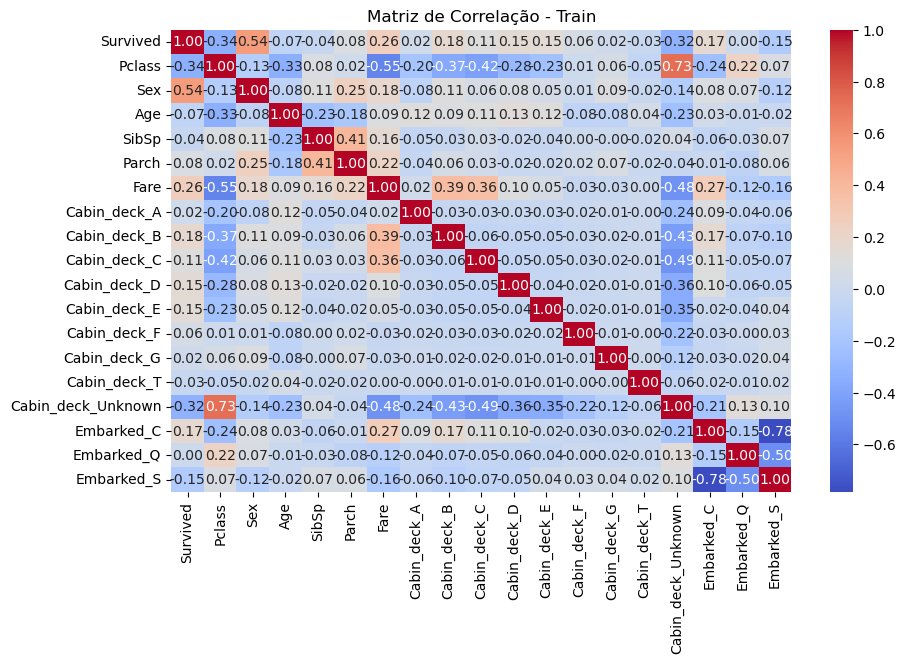

In [23]:
# Matriz de correlação
corr = train.corr(numeric_only=True)

plt.figure(figsize=(10,6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Matriz de Correlação - Train")
plt.show()

Matriz de correlação exploratória para entender relações numéricas.

In [24]:
X_train = train.drop(columns=['Survived'])

y_train = train['Survived']

X_test = X_test[X_train.columns]

# Normalizar
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# PCA
pca = PCA(n_components=0.95)  # mantém 95% da variância
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

print("Número de componentes escolhidos:", pca.n_components_)
print("\nVariância acumulada:\n", pca.explained_variance_ratio_.cumsum())
print("\nVariância explicada por cada componente:", pca.explained_variance_ratio_)

Número de componentes escolhidos: 14

Variância acumulada:
 [0.17949578 0.28263655 0.38272634 0.44792378 0.50916067 0.56912666
 0.62799753 0.6847567  0.74092047 0.79639444 0.84930947 0.89227963
 0.93123743 0.9612027 ]

Variância explicada por cada componente: [0.17949578 0.10314077 0.1000898  0.06519743 0.06123689 0.05996599
 0.05887087 0.05675917 0.05616377 0.05547397 0.05291502 0.04297016
 0.0389578  0.02996527]


# Modelos base
Optou-se por testar e comparar três algoritmos representativos:
 - Random Forest: considerado um baseline robusto e de fácil interpretação.
 - XGBoost: modelo de gradiente reforçado, geralmente mais preciso e competitivo.
 - SVC: classificador baseado em margens ótimas, adequado para conjuntos menores e bem definidos.

#### Random Forest - Basico

In [25]:
# Random Forest
rf = RandomForestClassifier(class_weight='balanced', random_state=42)
rf.fit(X_train_pca, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [26]:
y_pred_rf = rf.predict(X_train_pca)
relatorio_rf = classification_report(y_train, y_pred_rf)
print("Relatório de Classificação - Random Forest:")
print(relatorio_rf)

print("\nRandom Forest Accuracy:", accuracy_score(y_train, rf.predict(X_train_pca)))

Relatório de Classificação - Random Forest:
              precision    recall  f1-score   support

           0       0.98      1.00      0.99       549
           1       0.99      0.97      0.98       342

    accuracy                           0.99       891
   macro avg       0.99      0.98      0.99       891
weighted avg       0.99      0.99      0.99       891


Random Forest Accuracy: 0.9865319865319865


#### XGBoost - Basico

In [27]:
# XGBoost
scale_pos_weight = sum(y_train == 0) / sum(y_train == 1) #lida com desbalanceamento de classes usando o parâmetro scale_pos_weight, que ajusta o peso da classe positiva

xgb = XGBClassifier(scale_pos_weight=scale_pos_weight, random_state=42)
xgb.fit(X_train_pca, y_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,True
,eval_metric,None


In [28]:
y_pred_xgb = xgb.predict(X_train_pca)
relatorio_xgb = classification_report(y_train, y_pred_xgb)
print("Relatório de Classificação - XGBoost:")
print(relatorio_xgb)

print("\nXGBoost Accuracy:", accuracy_score(y_train, xgb.predict(X_train_pca)))

Relatório de Classificação - XGBoost:
              precision    recall  f1-score   support

           0       0.99      0.98      0.99       549
           1       0.97      0.99      0.98       342

    accuracy                           0.99       891
   macro avg       0.98      0.99      0.99       891
weighted avg       0.99      0.99      0.99       891


XGBoost Accuracy: 0.9865319865319865


#### SVC - Basico

In [29]:
# SVC
svc = SVC(class_weight='balanced', random_state=42)
svc.fit(X_train_pca, y_train)

,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,'balanced'
,verbose,False


In [30]:
y_pred_svc = svc.predict(X_train_pca)
relatorio_svc = classification_report(y_train, y_pred_svc)
print("Relatório de Classificação - XGBoost:")
print(relatorio_svc)

print("\nSVC Accuracy:", accuracy_score(y_train, svc.predict(X_train_pca)))

Relatório de Classificação - XGBoost:
              precision    recall  f1-score   support

           0       0.87      0.84      0.86       549
           1       0.76      0.79      0.78       342

    accuracy                           0.82       891
   macro avg       0.81      0.82      0.82       891
weighted avg       0.83      0.82      0.82       891


SVC Accuracy: 0.8237934904601572


# Modelos usando GridsearchCV

#### Random Forest

In [31]:
param_grid_rf = {
    'n_estimators': [100, 200],        # número de árvores
    'max_depth': [None, 5, 10],        # profundidade máxima da árvore
    'min_samples_split': [2, 5],       # mínimo de amostras para dividir um nó
    'min_samples_leaf': [1, 2],        # mínimo de amostras em uma folha
    'max_features': ['sqrt', 'log2']   # número de features consideradas em cada split
}

In [32]:
grid_rf = GridSearchCV(RandomForestClassifier(class_weight='balanced', random_state=42),
                       param_grid_rf,
                       cv=5,
                       verbose=2,
                       n_jobs=-1,
                       scoring='accuracy')
grid_rf.fit(X_train_pca, y_train)
print("Melhor RF:", grid_rf.best_params_)
print("Melhor Acurácia:", grid_rf.best_score_)

Fitting 5 folds for each of 48 candidates, totalling 240 fits
Melhor RF: {'max_depth': 5, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
Melhor Acurácia: 0.8013495700207143


In [33]:
best_rf_model = grid_rf.best_estimator_
y_pred_rf_grid = best_rf_model.predict(X_train_pca)

relatorio_best_rf = classification_report(y_train, y_pred_rf_grid)

print("Relatório de Classificação - 'Best' Random Forest:")
print(relatorio_best_rf)

print("\n'Best' Random Forest Accuracy:", accuracy_score(y_train, best_rf_model.predict(X_train_pca)))

Relatório de Classificação - 'Best' Random Forest:
              precision    recall  f1-score   support

           0       0.90      0.87      0.88       549
           1       0.80      0.85      0.82       342

    accuracy                           0.86       891
   macro avg       0.85      0.86      0.85       891
weighted avg       0.86      0.86      0.86       891


'Best' Random Forest Accuracy: 0.8574635241301908


#### XGBoost

In [34]:
param_grid_xgb = {
    'n_estimators': [100, 200],        # número de árvores
    'max_depth': [3, 5, 7],            # profundidade máxima
    'learning_rate': [0.01, 0.1],      # taxa de aprendizado
    'subsample': [0.8, 1.0],           # fração de amostras usadas por árvore
    'colsample_bytree': [0.8, 1.0]     # fração de features usadas por árvore
}

In [35]:
grid_xgb = GridSearchCV(XGBClassifier(scale_pos_weight=scale_pos_weight, random_state=42,),
                        param_grid_xgb,
                        cv=5,
                        verbose=2,
                        n_jobs=-1,
                        scoring='accuracy')

grid_xgb.fit(X_train_pca, y_train)
print("Melhor XGB:", grid_xgb.best_params_)
print("Melhor Acurácia:", grid_xgb.best_score_)

Fitting 5 folds for each of 48 candidates, totalling 240 fits
Melhor XGB: {'colsample_bytree': 1.0, 'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 200, 'subsample': 0.8}
Melhor Acurácia: 0.8002385286548239


In [36]:
best_xgb_model = grid_xgb.best_estimator_
y_pred_xgb_grid = best_xgb_model.predict(X_train_pca)

relatorio_best_xgb = classification_report(y_train, y_pred_xgb_grid)

print("Relatório de Classificação - 'Best' XGBoost:")
print(relatorio_best_xgb)

print("\n'Best' XGBoost Accuracy:", accuracy_score(y_train, best_xgb_model.predict(X_train_pca)))

Relatório de Classificação - 'Best' XGBoost:
              precision    recall  f1-score   support

           0       0.95      0.95      0.95       549
           1       0.92      0.92      0.92       342

    accuracy                           0.94       891
   macro avg       0.93      0.93      0.93       891
weighted avg       0.94      0.94      0.94       891


'Best' XGBoost Accuracy: 0.9371492704826038


#### SVC

In [37]:
param_grid_svc = {
    'C': [0.1, 1, 2],                   # penalidade de erro (regularização)
    'kernel': ['linear', 'rbf', 'poly'], # tipo de função kernel
    'gamma': ['scale', 'auto'],          # parâmetro do kernel RBF
    'degree': [2, 3],                    # grau do polinômio (se kernel='poly')
    'class_weight': ['balanced', None]   # peso das classes para desbalanceamento
}

In [38]:
grid_svc = GridSearchCV(SVC(random_state=42),
                        param_grid_svc,
                        cv=5,
                        verbose=2,
                        n_jobs=-1,
                        scoring='accuracy')

grid_svc.fit(X_train_pca, y_train)
print("Melhor SVC:", grid_svc.best_params_)
print("Melhor Acurácia:", grid_svc.best_score_)

Fitting 5 folds for each of 72 candidates, totalling 360 fits
Melhor SVC: {'C': 2, 'class_weight': None, 'degree': 2, 'gamma': 'auto', 'kernel': 'rbf'}
Melhor Acurácia: 0.8092021844203126


In [39]:
best_svc_model = grid_svc.best_estimator_
y_pred_svc_grid = best_svc_model.predict(X_train_pca)

relatorio_best_svc = classification_report(y_train, y_pred_svc_grid)

print("Relatório de Classificação - 'Best' SVC:")
print(relatorio_best_svc)

print("\n'Best' SVC Accuracy:", accuracy_score(y_train, best_svc_model.predict(X_train_pca)))

Relatório de Classificação - 'Best' SVC:
              precision    recall  f1-score   support

           0       0.86      0.90      0.88       549
           1       0.82      0.76      0.79       342

    accuracy                           0.85       891
   macro avg       0.84      0.83      0.83       891
weighted avg       0.84      0.85      0.84       891


'Best' SVC Accuracy: 0.8451178451178452


Gerar csv para resposta

In [40]:
Y_rf = rf.predict(X_test_pca)
sub_rf = pd.Series(Y_rf, index=test['PassengerId'], name = 'Survived')

sub_rf

PassengerId
892     0
893     0
894     0
895     1
896     0
       ..
1305    0
1306    1
1307    0
1308    0
1309    1
Name: Survived, Length: 418, dtype: int64

In [41]:
sub_rf.to_csv("rf.csv" , header=True)

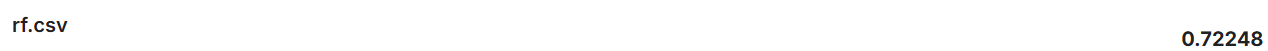

In [42]:
Y_xgb = xgb.predict(X_test_pca)
sub_xgb = pd.Series(Y_xgb, index=test['PassengerId'], name = 'Survived')

sub_xgb

PassengerId
892     0
893     0
894     0
895     1
896     0
       ..
1305    0
1306    1
1307    0
1308    0
1309    1
Name: Survived, Length: 418, dtype: int64

In [43]:
sub_xgb.to_csv("xgb.csv" , header=True)

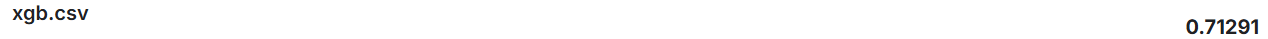

In [44]:
Y_svc = svc.predict(X_test_pca)
sub_svc = pd.Series(Y_svc, index=test['PassengerId'], name = 'Survived')

sub_svc

PassengerId
892     0
893     1
894     0
895     0
896     1
       ..
1305    0
1306    1
1307    0
1308    0
1309    0
Name: Survived, Length: 418, dtype: int64

In [45]:
sub_svc.to_csv("svc.csv" , header=True)

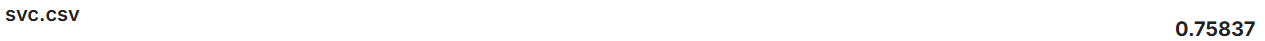

In [46]:
Y_best_rf = best_rf_model.predict(X_test_pca)
sub_best_rf = pd.Series(Y_best_rf, index=test['PassengerId'], name = 'Survived')

sub_best_rf

PassengerId
892     0
893     1
894     0
895     0
896     1
       ..
1305    0
1306    1
1307    0
1308    0
1309    0
Name: Survived, Length: 418, dtype: int64

In [47]:
sub_best_rf.to_csv("best_rf.csv" , header=True)

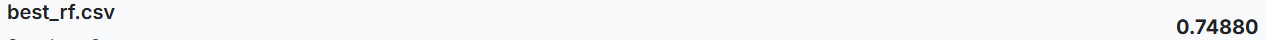

In [48]:
Y_best_xgb = best_xgb_model.predict(X_test_pca)
sub_best_xgb = pd.Series(Y_best_xgb, index=test['PassengerId'], name = 'Survived')

sub_best_xgb

PassengerId
892     0
893     0
894     0
895     0
896     0
       ..
1305    0
1306    1
1307    0
1308    0
1309    1
Name: Survived, Length: 418, dtype: int64

In [49]:
sub_best_xgb.to_csv("best_xgb.csv" , header=True)

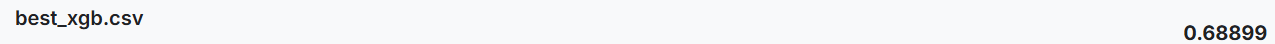

In [50]:
Y_best_svc = best_svc_model.predict(X_test_pca)
sub_best_svc = pd.Series(Y_best_svc, index=test['PassengerId'], name = 'Survived')

sub_best_svc

PassengerId
892     0
893     1
894     0
895     0
896     1
       ..
1305    0
1306    1
1307    0
1308    0
1309    0
Name: Survived, Length: 418, dtype: int64

In [51]:
sub_best_svc.to_csv("best_svc.csv" , header=True)

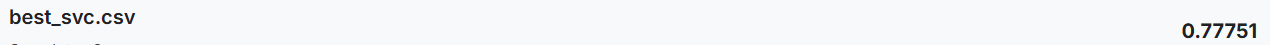

Conclusão:
A Ilusão do Desempenho Local (Overfitting)
Os resultados locais (antes do envio) mostraram números extremamente altos para os modelos base, o que indica potencial Overfitting aos dados:
 - Random Forest (Base): ~98,6% de acurácia
 - XGBoost (Base): ~98,6% de acurácia
 - SVC (Base): ~82,3% de acurácia

Ao aplicar o GridSearchCV, os resultados locais caíram:
 - Best Random Forest: Caiu de 98% para 85,7%
 - Best XGBoost: Caiu de 98% para 93,7%
 - Best SVC: Subiu levemente para 84,5%.

O GridSearch: Ironicamente "piora" nos resultados locais do Random Forest e do XGBoost, mas isso se deve aos modelos ficarem mais simples (poda), diminuindo a memorização (overfitting) e forçando-os a focar nos padrões reais.

Os Scores fo Kaggle mostram que o melhor modelo foi o SVC otimizado pelo GridSearchCV, obtendo um resultado de 0,77751, que como esperado, é inferior ao demonstrado pelos resultados locais, usando a base de treino.